# 01. Data Collection

### What are we investigating?
We use the pandas GitHub issue tracker to examine how issue ownership relates to resolution time and workload. The analysis focuses on closed issues so that each issue has a measurable end point.

**Why this matters:** Understanding where issues spend time and how work is distributed can help a software team identify process bottlenecks, ownership gaps, and potential workload concentration.


In [2]:
import os
import requests
import pandas as pd
import time

TOKEN = os.getenv("GITHUB_TOKEN")
headers = {"Authorization": f"token {TOKEN}"}
url = "https://api.github.com/repos/pandas-dev/pandas/issues"

all_issues = []
page = 1
max_pages = 100  # 100 pages x 100 per page = up to 10,000 issues

while page <= max_pages:
    params = {
        "state": "closed",
        "per_page": 100,
        "page": page
    }
    response = requests.get(url, headers=headers, params=params)
    
    if response.status_code != 200:
        print(f"Stopped at page {page}, status: {response.status_code}")
        break
    
    data = response.json()
    if not data:  # empty page = no more results
        print(f"No more data at page {page}")
        break
    
    all_issues.extend(data)
    print(f"Page {page}: pulled {len(data)} items (total so far: {len(all_issues)})")
    
    page += 1
    time.sleep(0.3)  # be polite to the API

print(f"\nDone. Total issues pulled: {len(all_issues)}")

Page 1: pulled 100 items (total so far: 100)
Page 2: pulled 100 items (total so far: 200)
Page 3: pulled 100 items (total so far: 300)
Page 4: pulled 100 items (total so far: 400)
Page 5: pulled 100 items (total so far: 500)
Page 6: pulled 100 items (total so far: 600)
Page 7: pulled 100 items (total so far: 700)
Page 8: pulled 100 items (total so far: 800)
Page 9: pulled 100 items (total so far: 900)
Page 10: pulled 100 items (total so far: 1000)
Page 11: pulled 100 items (total so far: 1100)
Page 12: pulled 100 items (total so far: 1200)
Page 13: pulled 100 items (total so far: 1300)
Page 14: pulled 100 items (total so far: 1400)
Page 15: pulled 100 items (total so far: 1500)
Page 16: pulled 100 items (total so far: 1600)
Page 17: pulled 100 items (total so far: 1700)
Page 18: pulled 100 items (total so far: 1800)
Page 19: pulled 100 items (total so far: 1900)
Page 20: pulled 100 items (total so far: 2000)
Page 21: pulled 100 items (total so far: 2100)
Page 22: pulled 100 items (tota

### Preserve the Raw Extract

We save the API extract before transforming it so the original dataset is preserved as a reproducible starting point. This also separates data collection from the analytical preparation steps that follow.


In [3]:
df = pd.DataFrame(all_issues)
df.to_csv("pandas_issues_raw.csv", index=False)
print(df.shape)

(9900, 36)


# 02. Data Validation & Preparation

### Re-load the Extract for Analysis

We reload the saved dataset and inspect its shape and first records. This confirms that the exported data can be used independently of the API collection step and gives us a first look at the available issue attributes.


In [4]:
import pandas as pd

df = pd.read_csv("pandas_issues_raw.csv")
print(df.shape)
df.head()

(9900, 36)


,url,repository_url,labels_url,comments_url,events_url,html_url,id,node_id,number,title,...,pull_request,body,closed_by,reactions,timeline_url,performed_via_github_app,state_reason,sub_issues_summary,issue_dependencies_summary,pinned_comment
0,https://api.github.com/repos/pandas-dev/pandas...,https://api.github.com/repos/pandas-dev/pandas,https://api.github.com/repos/pandas-dev/pandas...,https://api.github.com/repos/pandas-dev/pandas...,https://api.github.com/repos/pandas-dev/pandas...,https://github.com/pandas-dev/pandas/pull/66784,5159500655,PR_kwDOAA0YD87_e-yN,66784,Add GitHub practice file,...,{'url': 'https://api.github.com/repos/pandas-d...,## Summary\r\n\r\nAdded a practice file while ...,"{'login': 'jbrockmendel', 'id': 8078968, 'node...",{'url': 'https://api.github.com/repos/pandas-d...,https://api.github.com/repos/pandas-dev/pandas...,NaN,NaN,NaN,NaN,NaN
1,https://api.github.com/repos/pandas-dev/pandas...,https://api.github.com/repos/pandas-dev/pandas,https://api.github.com/repos/pandas-dev/pandas...,https://api.github.com/repos/pandas-dev/pandas...,https://api.github.com/repos/pandas-dev/pandas...,https://github.com/pandas-dev/pandas/pull/66773,5157365979,PR_kwDOAA0YD87_Yb4K,66773,doc: clarify dict_keys acceptance in DataFrame...,...,{'url': 'https://api.github.com/repos/pandas-d...,Fixes #66742\n\n### Context & Documentation En...,"{'login': 'jbrockmendel', 'id': 8078968, 'node...",{'url': 'https://api.github.com/repos/pandas-d...,https://api.github.com/repos/pandas-dev/pandas...,NaN,NaN,NaN,NaN,NaN
2,https://api.github.com/repos/pandas-dev/pandas...,https://api.github.com/repos/pandas-dev/pandas,https://api.github.com/repos/pandas-dev/pandas...,https://api.github.com/repos/pandas-dev/pandas...,https://api.github.com/repos/pandas-dev/pandas...,https://github.com/pandas-dev/pandas/pull/66770,5157099962,PR_kwDOAA0YD87_Xnky,66770,BUG: to_numpy with a unit-less datetime64 dtyp...,...,{'url': 'https://api.github.com/repos/pandas-d...,closes #59772\n\nnumpy discards a unit-less `d...,"{'login': 'jbrockmendel', 'id': 8078968, 'node...",{'url': 'https://api.github.com/repos/pandas-d...,https://api.github.com/repos/pandas-dev/pandas...,NaN,NaN,NaN,NaN,NaN
3,https://api.github.com/repos/pandas-dev/pandas...,https://api.github.com/repos/pandas-dev/pandas,https://api.github.com/repos/pandas-dev/pandas...,https://api.github.com/repos/pandas-dev/pandas...,https://api.github.com/repos/pandas-dev/pandas...,https://github.com/pandas-dev/pandas/pull/66767,5154525221,PR_kwDOAA0YD87_PZul,66767,DOC: require human-written comments and specif...,...,{'url': 'https://api.github.com/repos/pandas-d...,Clarifies the automated contributions policy o...,"{'login': 'jbrockmendel', 'id': 8078968, 'node...",{'url': 'https://api.github.com/repos/pandas-d...,https://api.github.com/repos/pandas-dev/pandas...,NaN,NaN,NaN,NaN,NaN
4,https://api.github.com/repos/pandas-dev/pandas...,https://api.github.com/repos/pandas-dev/pandas,https://api.github.com/repos/pandas-dev/pandas...,https://api.github.com/repos/pandas-dev/pandas...,https://api.github.com/repos/pandas-dev/pandas...,https://github.com/pandas-dev/pandas/pull/66762,5153003758,PR_kwDOAA0YD87_Kgpj,66762,DEPR: clarify deprecation warning for date_for...,...,{'url': 'https://api.github.com/repos/pandas-d...,I find the current deprecation message not _su...,"{'login': 'jbrockmendel', 'id': 8078968, 'node...",{'url': 'https://api.github.com/repos/pandas-d...,https://api.github.com/repos/pandas-dev/pandas...,NaN,NaN,NaN,NaN,NaN


### Define the Issue Population

GitHub's issue endpoint can include pull requests. Because the business question concerns issue management rather than code-review activity, we remove pull requests and retain genuine issues for the analysis.


In [5]:
# If the pull_request column has a value (not null), it's a PR - so i am dropping those
df_issues = df[df["pull_request"].isna()].copy()
print(f"Original: {len(df)}, After removing PRs: {len(df_issues)}")

Original: 9900, After removing PRs: 2293


### Create the Core Performance Metric

We convert the creation and closure timestamps into a **cycle-time metric**, measured in days. This becomes the primary measure of how long an issue takes to move from creation to resolution.

**Why this matters:** A consistent cycle-time measure lets us compare issue types and ownership groups on the same operational dimension.


In [6]:
df_issues["created_at"] = pd.to_datetime(df_issues["created_at"])
df_issues["closed_at"] = pd.to_datetime(df_issues["closed_at"])

df_issues["cycle_time_days"] = (df_issues["closed_at"] - df_issues["created_at"]).dt.total_seconds() / 86400

print(df_issues["cycle_time_days"].describe())

count    2293.000000
mean      105.830543
std       202.715937
min         0.000139
25%         0.954236
50%         9.476169
75%        90.282350
max       980.130891
Name: cycle_time_days, dtype: float64


### Prepare Issue Categories

We extract the individual label names from GitHub's nested label structure. This turns the raw metadata into usable analytical categories, allowing us to compare issue types such as bugs across different ownership groups.


In [8]:
import ast

def extract_labels(label_str):
    try:
        labels = ast.literal_eval(label_str) if isinstance(label_str, str) else label_str
        return [l["name"] for l in labels]
    except:
        return []

df_issues["label_names"] = df_issues["labels"].apply(extract_labels)

# 03. Ownership & Resolution Performance

### Question: How Much of the Work Is Assigned?

We identify whether each issue has an assignee. This creates the central comparison used throughout the analysis: **assigned vs. unassigned issues**.

The goal is to understand whether explicit ownership is associated with faster issue resolution.


In [9]:
df_issues["has_assignee"] = df_issues["assignee"].notna()
print(df_issues["has_assignee"].value_counts())

has_assignee
False    1834
True      459
Name: count, dtype: int64


### Question: Is Ownership Associated With Faster Resolution?

We compare median and average cycle time between assigned and unassigned issues. Using both measures helps distinguish the typical experience from the effect of unusually long-running issues.


In [10]:
print(df_issues.groupby("has_assignee")["cycle_time_days"].median())
print(df_issues.groupby("has_assignee")["cycle_time_days"].mean())

has_assignee
False     6.134716
True     36.101343
Name: cycle_time_days, dtype: float64
has_assignee
False     96.475765
True     143.208891
Name: cycle_time_days, dtype: float64


### Question: Are Different Types of Issues Being Assigned Differently?

We compare the most common labels among assigned and unassigned issues. This helps determine whether the ownership difference is concentrated in particular categories rather than being uniform across the issue population.


In [11]:
# See what labels are common on assigned vs unassigned issues
assigned_labels = df_issues[df_issues["has_assignee"]]["label_names"].explode().value_counts().head(10)
unassigned_labels = df_issues[~df_issues["has_assignee"]]["label_names"].explode().value_counts().head(10)

print("Top labels — ASSIGNED issues:")
print(assigned_labels)
print("\nTop labels — UNASSIGNED issues:")
print(unassigned_labels)

Top labels — ASSIGNED issues:
label_names
Bug             247
Docs            119
Needs Triage     54
Enhancement      41
Groupby          30
Reshaping        28
Arrow            27
Missing-data     26
Indexing         23
Datetime         23
Name: count, dtype: int64

Top labels — UNASSIGNED issues:
label_names
Bug                  876
Needs Triage         459
Closing Candidate    259
Enhancement          239
Docs                 237
Needs Info           106
Arrow                103
Performance           96
Needs Discussion      91
Build                 90
Name: count, dtype: int64


# 04. Focus on Bug Resolution

### Question: Does Assignment Matter for Bugs Specifically?

Bugs are isolated as a high-priority issue category and their cycle times are compared by assignment status. Focusing on one consistent issue type provides a more targeted test of whether ownership is associated with resolution speed.


In [12]:
bug_issues = df_issues[df_issues["label_names"].apply(lambda x: "Bug" in x)]

print(bug_issues.groupby("has_assignee")["cycle_time_days"].median())
print(bug_issues.groupby("has_assignee")["cycle_time_days"].count())

has_assignee
False     5.078223
True     55.192454
Name: cycle_time_days, dtype: float64
has_assignee
False    876
True     247
Name: cycle_time_days, dtype: int64


### Investigate Long-Running Assigned Bugs

We examine examples of assigned bugs that remain open for more than 100 days. The purpose is not to treat individual issues as proof of a systemic problem, but to identify concrete cases that can help explain where long cycle times may occur.


In [13]:
sample = bug_issues[bug_issues["has_assignee"] & (bug_issues["cycle_time_days"] > 100)][["title", "html_url", "cycle_time_days"]].head(5)
print(sample)

                                                  title  \
2901  BUG: 3.0rc0: comparing `StringArray`s with `==...   
3780           BUG: `np.isnan` raises on pyarrow dtypes   
3832  BUG: NumpyEA[uint8].take([-1], allow_fill=True...   
3857       BUG: Incorrect results for pandas.Series.var   
3933  BUG: _get_common_dtype with date32[pyarrow] an...   

                                               html_url  cycle_time_days  
2901  https://github.com/pandas-dev/pandas/issues/63458       194.178750  
3780  https://github.com/pandas-dev/pandas/issues/62506       212.577639  
3832  https://github.com/pandas-dev/pandas/issues/62448       109.131782  
3857  https://github.com/pandas-dev/pandas/issues/62421       184.441806  
3933  https://github.com/pandas-dev/pandas/issues/62343       328.463414  


# 05. Look for Signs of Idle Work

### Question: Are Long-Running Issues Showing Little Discussion?

GitHub's dataset does not provide a first-response timestamp in the fields used here, so comment count is used as a **proxy for interaction activity**. We then identify issues with zero comments that nevertheless take more than 30 days to close.

**Interpretation:** These cases are candidates for further investigation because they may indicate work that remained idle or received limited visible interaction.


In [14]:
# Quick proxy analysis using comment count instead of first-response timestamp
print(df_issues.groupby("has_assignee")["comments"].median())
print(df_issues.groupby("has_assignee")["comments"].mean())

# Zero-comment issues with long cycle time = likely "sat idle"
idle_candidates = df_issues[(df_issues["comments"] == 0) & (df_issues["cycle_time_days"] > 30)]
print(f"\nIssues with 0 comments but >30 days to close: {len(idle_candidates)}")
print(idle_candidates[["title", "has_assignee", "cycle_time_days"]].head(10))

has_assignee
False    2.0
True     4.0
Name: comments, dtype: float64
has_assignee
False    3.799346
True     5.525054
Name: comments, dtype: float64

Issues with 0 comments but >30 days to close: 30
                                                  title  has_assignee  \
825   BUG: `DataFrame.any`/`all(skipna=False)` raise...         False   
868   BUG: DataFrame.melt silently corrupts data on ...         False   
1124       PERF: cache BlockManager.get_dtypes() result         False   
1375  BUG: Regression when using `.str[...]` accesso...         False   
1420  BUG: ADBCDatabase does not escape SQL identifi...         False   
1793  BUG: C engine of `read_csv` converts `1 ,` to ...         False   
2611  BUG: `DataFrame.from_records` ignores exclude ...         False   
4105             REF: use _cast_pointwise_result in map          True   
4308  BUG: `assert_index_equal(CategoricalIndex, Cat...         False   
4377  BUG: DateOffset default temporal pattern does ...          True 

# 06. Workload Concentration

### Question: Is Bug Ownership Concentrated Among a Small Group of Contributors?

We extract contributor identities for assigned bugs and rank them by issue count. This shows how broadly bug-resolution work is distributed and whether a small number of contributors handle a disproportionate share of assigned bugs.

**Why this matters:** Strong concentration can create capacity and continuity risks if key contributors become unavailable.


In [15]:
# Who's handling assigned issues? (assignee is a dict, need to extract login)
import ast

def get_assignee_login(a):
    try:
        d = ast.literal_eval(a) if isinstance(a, str) else a
        return d.get("login") if d else None
    except:
        return None

bug_issues_assigned = bug_issues[bug_issues["has_assignee"]].copy()
bug_issues_assigned["assignee_login"] = bug_issues_assigned["assignee"].apply(get_assignee_login)

top_assignees = bug_issues_assigned["assignee_login"].value_counts()
print(top_assignees.head(10))
print(f"\nTotal unique assignees: {top_assignees.shape[0]}")
print(f"Top 3 assignees handle: {top_assignees.head(3).sum()} of {top_assignees.sum()} issues ({top_assignees.head(3).sum()/top_assignees.sum()*100:.1f}%)")

assignee_login
rhshadrach        15
jbrockmendel      11
snitish           11
Anurag-Varma       7
matiaslindgren     6
skalwaghe-56       6
KevsterAmp         6
rob-sil            5
heoh               4
khemkaran10        4
Name: count, dtype: int64

Total unique assignees: 146
Top 3 assignees handle: 37 of 247 issues (15.0%)


# 07. Prepare the Dataset for Reporting

### Create Analysis-Ready Fields

We flatten the label structure and create simpler category and assignee fields so the cleaned dataset can be consumed easily in Power BI or other reporting tools. The objective is to turn the analytical work into a reusable reporting dataset rather than leaving the findings inside the notebook only.


In [16]:
# Flatten labels into a comma-separated string for easier use in Power BI
df_issues["labels_flat"] = df_issues["label_names"].apply(lambda x: ", ".join(x) if x else "")

# Add primary label (first one) as a simpler category field for filteraing
df_issues["primary_label"] = df_issues["label_names"].apply(lambda x: x[0] if x else "None")

# Extract assignee login cleanly (reuse the function from before)
df_issues["assignee_login"] = df_issues["assignee"].apply(get_assignee_login)

# Export
df_issues.to_csv("pandas_issues_clean.csv", index=False)
print("Exported:", df_issues.shape)

Exported: (2293, 42)


# 08. Visualize the Key Findings

### Visualize the Distribution of Resolution Time

The first chart shows the overall distribution of issue cycle time, with the median and mean highlighted. This provides context for the typical resolution time while also making the long tail of slow-moving issues visible.


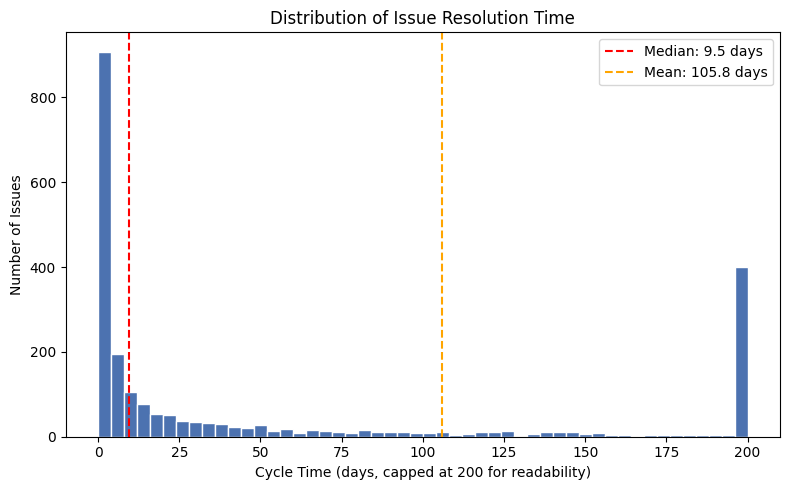

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df_issues["cycle_time_days"].clip(upper=200), bins=50, color="#4C72B0", edgecolor="white")
plt.axvline(df_issues["cycle_time_days"].median(), color="red", linestyle="--", label=f'Median: {df_issues["cycle_time_days"].median():.1f} days')
plt.axvline(df_issues["cycle_time_days"].mean(), color="orange", linestyle="--", label=f'Mean: {df_issues["cycle_time_days"].mean():.1f} days')
plt.xlabel("Cycle Time (days, capped at 200 for readability)")
plt.ylabel("Number of Issues")
plt.title("Distribution of Issue Resolution Time")
plt.legend()
plt.tight_layout()
plt.savefig("chart1_cycle_time_distribution.png", dpi=150)
plt.show()

### Visualize the Ownership Comparison

This chart turns the central assigned-vs-unassigned bug comparison into an immediately readable business takeaway. The focus is on **median cycle time**, which represents the typical resolution experience while being less sensitive to extreme outliers than the mean.


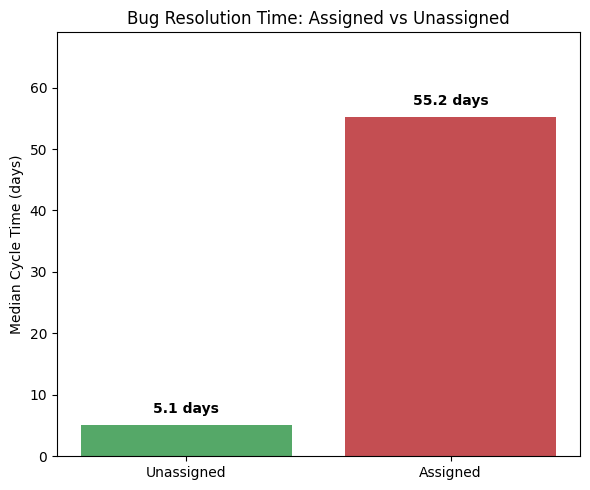

In [20]:
plt.figure(figsize=(6,5))
bars = plt.bar(comparison.index, comparison.values, color=["#55A868", "#C44E52"])
plt.ylabel("Median Cycle Time (days)")
plt.title("Bug Resolution Time: Assigned vs Unassigned")
plt.ylim(0, comparison.values.max() * 1.25)  # add headroom for labels
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 2, f'{height:.1f} days', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig("chart2_assigned_vs_unassigned.png", dpi=150)
plt.show()

### Visualize Contributor Workload

The final contributor view ranks the top assignees by the number of assigned bugs they handle. This makes workload distribution visible and helps assess whether the process appears dependent on a small number of individuals.


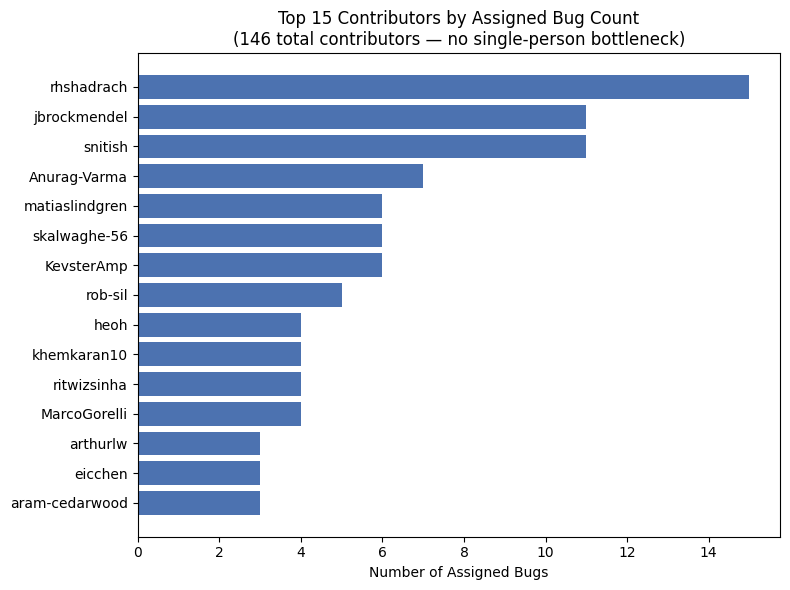

In [21]:
top_assignees_full = bug_issues_assigned["assignee_login"].value_counts().head(15)

plt.figure(figsize=(8,6))
plt.barh(top_assignees_full.index[::-1], top_assignees_full.values[::-1], color="#4C72B0")
plt.xlabel("Number of Assigned Bugs")
plt.title("Top 15 Contributors by Assigned Bug Count\n(146 total contributors — no single-person bottleneck)")
plt.tight_layout()
plt.savefig("chart3_assignee_distribution.png", dpi=150)
plt.show()